# Phase 1 Dataset: Exploratory Analysis

Loads the 5,815-sector micro-sector dataset produced by the full 2025 season run.
Three goals:

1. **Sanity-check** the feature distributions against expectations from the proposal.
2. **Identify outliers** that the 107%-filter pass should remove (slow laps, low v_min, anomalous apex counts).
3. **Produce figures** suitable for the dissertation's validation chapter — exported to `../figures/` as PDF.

Run all cells top-to-bottom. Figures save automatically; tables print inline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths are relative to the workspace root, which is the kernel's
# working directory (set by jupyter.notebookFileRoot in .vscode/settings.json).
OUTPUT_DIR = Path('output')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Load the season parquet
df = pd.read_parquet(OUTPUT_DIR / 'microsectors_2025_Q.parquet')
diag = pd.read_parquet(OUTPUT_DIR / 'diagnostics_2025_Q.parquet')

print(f'Loaded {len(df):,} micro-sectors across {df["gp"].nunique()} GPs '
      f'({df["driver"].nunique()} unique drivers)')
print(f'Diagnostics: {len(diag):,} driver-session quality records')
print(f'\nColumns: {list(df.columns)}')
df.head()

Loaded 5,748 micro-sectors across 24 GPs (21 unique drivers)
Diagnostics: 469 driver-session quality records

Columns: ['year', 'gp', 'session', 'driver', 'lap_time_s', 'detector', 'n_apexes', 'sector_id', 'apex_start_m', 'apex_end_m', 'L_straight_m', 'v_exit_kph', 'v_entry_target_kph', 'v_max_kph', 'v_min_kph', 'rel_pos_vmax', 'full_throttle_frac', 'lift_frac', 'brake_frac', 'kappa_max_mid_1pm', 'kappa_mean_1pm', 'apex_start_corner', 'apex_end_corner', 'n_samples']


,year,gp,session,driver,lap_time_s,detector,n_apexes,sector_id,apex_start_m,apex_end_m,...,v_min_kph,rel_pos_vmax,full_throttle_frac,lift_frac,brake_frac,kappa_max_mid_1pm,kappa_mean_1pm,apex_start_corner,apex_end_corner,n_samples
0,2025,Australian Grand Prix,Q,NOR,75.096,circuit_info,14,1,366.253509,1076.253509,...,108.860319,0.792135,0.797753,0.179775,0.168539,0.000751,0.000434,2,3,356
1,2025,Australian Grand Prix,Q,NOR,75.096,circuit_info,14,2,1076.253509,1194.253509,...,108.860319,0.683333,0.283333,0.400000,0.000000,0.001153,0.001032,3,4,60
2,2025,Australian Grand Prix,Q,NOR,75.096,circuit_info,14,3,1194.253509,1364.253509,...,161.793048,0.988372,0.755814,0.023256,0.000000,0.000989,0.000689,4,5,86
3,2025,Australian Grand Prix,Q,NOR,75.096,circuit_info,14,4,1364.253509,1866.253509,...,233.392182,0.742063,0.757937,0.186508,0.099206,0.000781,0.000472,5,6,252
4,2025,Australian Grand Prix,Q,NOR,75.096,circuit_info,14,6,1890.253509,2090.253509,...,239.156864,0.990099,1.000000,0.000000,0.000000,0.000526,0.000444,7,8,101


## 1. Coverage: sectors per Grand Prix

Quick check that no event silently dropped out. Expect 200-300 sectors per GP
(roughly 17 drivers × 15-18 sectors per lap).

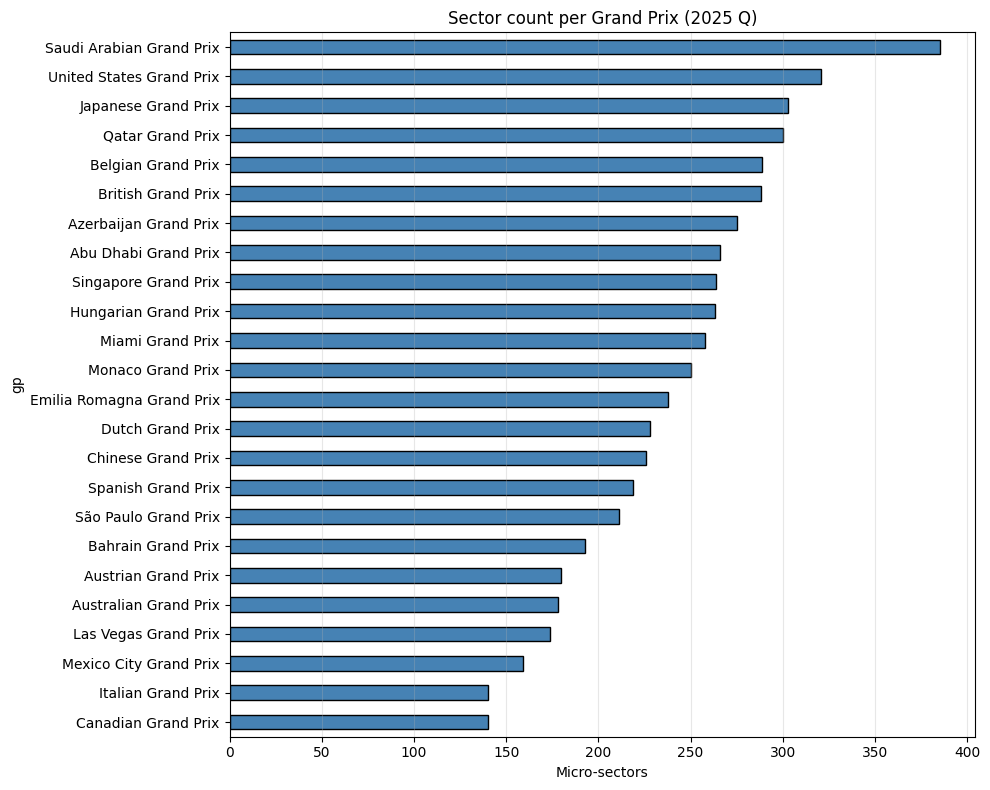


Sector count: min=140, median=244, max=385
Total: 5,748


In [2]:
gp_counts = df['gp'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
gp_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Micro-sectors')
ax.set_title('Sector count per Grand Prix (2025 Q)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sectors_per_gp.pdf', bbox_inches='tight')
plt.show()

print(f'\nSector count: min={gp_counts.min()}, '
      f'median={int(gp_counts.median())}, max={gp_counts.max()}')
print(f'Total: {gp_counts.sum():,}')

## 2. Lap-time distribution per GP

Each driver-session contributes one fastest lap time. This view spots
outliers from drivers whose 'fastest' lap was actually a slow lap (red
flag laps, only one Q1 attempt completed, etc.).

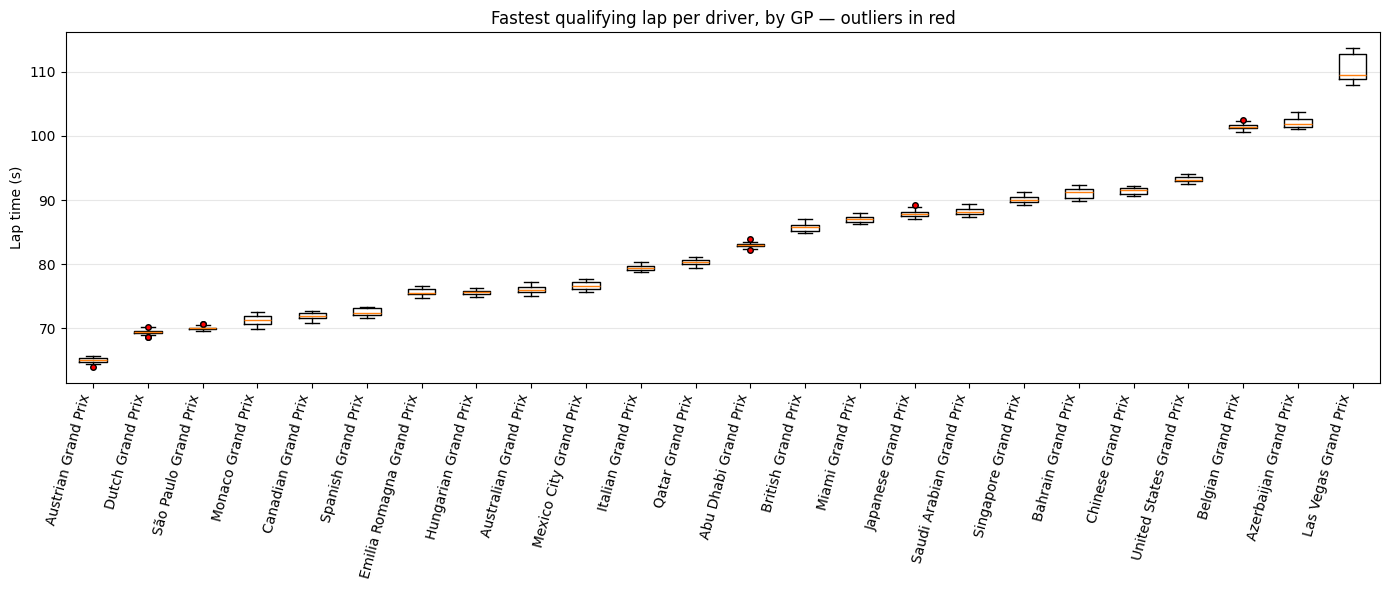

In [3]:
# One row per (gp, driver) - the fastest lap
lap_times = df.groupby(['gp', 'driver'])['lap_time_s'].first().reset_index()

# Order GPs by median lap time (short circuits first)
order = lap_times.groupby('gp')['lap_time_s'].median().sort_values().index
gp_data = [lap_times[lap_times['gp'] == gp]['lap_time_s'].values for gp in order]

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(gp_data, tick_labels=order, vert=True, showfliers=True,
           flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=75, ha='right')
ax.set_ylabel('Lap time (s)')
ax.set_title('Fastest qualifying lap per driver, by GP — outliers in red')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'laptime_per_gp.pdf', bbox_inches='tight')
plt.show()

### 2a. Slow-lap outliers (>107% of session fastest)

F1's classic 107% rule. Any driver whose 'fastest' lap is >7% off the
session leader's pace almost certainly wasn't a representative flying
lap. These are the targets for the loader-level filter in step 3.

In [4]:
# Compute each driver's lap time as a percentage above their session's fastest.
# Using groupby().transform() keeps the original frame structure intact and
# avoids the groupby/apply gotcha where include_groups=False drops 'gp'.
lap_times_rel = lap_times.copy()
fastest_per_gp = lap_times.groupby('gp')['lap_time_s'].transform('min')
lap_times_rel['rel_pace_pct'] = (
    lap_times_rel['lap_time_s'] / fastest_per_gp - 1
) * 100

slow_laps = lap_times_rel[lap_times_rel['rel_pace_pct'] > 7].sort_values(
    'rel_pace_pct', ascending=False
)
print(f'Drivers >107% off pace: {len(slow_laps)} out of {len(lap_times)} '
      f'({100*len(slow_laps)/len(lap_times):.1f}%)')
print(f'\nSectors contributed by these slow laps: '
      f'{df.merge(slow_laps[["gp", "driver"]], on=["gp", "driver"]).shape[0]}')
print()
slow_laps.head(15)

Drivers >107% off pace: 0 out of 469 (0.0%)

Sectors contributed by these slow laps: 0



,gp,driver,lap_time_s,rel_pace_pct


## 3. Velocity distributions

Sanity-check on the kinematic boundary conditions the OCP will use.

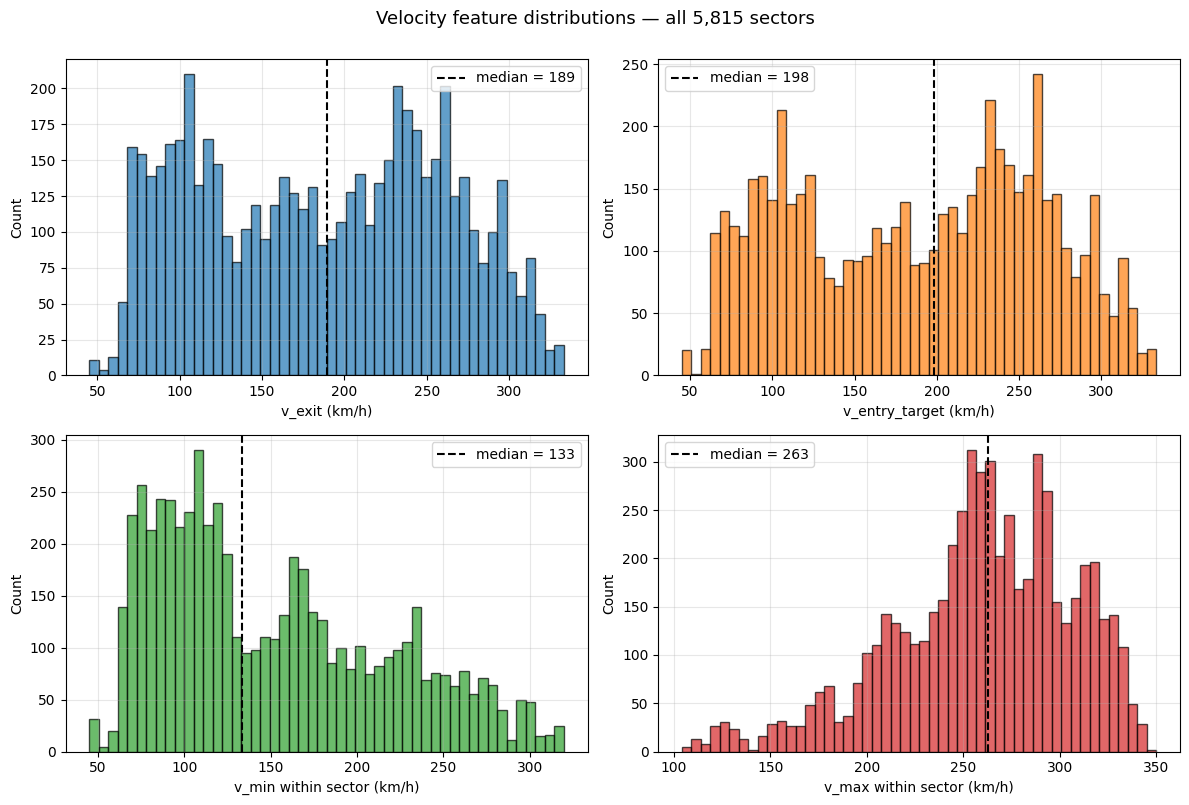

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [
    ('v_exit_kph', 'v_exit (km/h)', 'tab:blue'),
    ('v_entry_target_kph', 'v_entry_target (km/h)', 'tab:orange'),
    ('v_min_kph', 'v_min within sector (km/h)', 'tab:green'),
    ('v_max_kph', 'v_max within sector (km/h)', 'tab:red'),
]
for ax, (col, label, c) in zip(axes.flat, specs):
    ax.hist(df[col], bins=50, color=c, edgecolor='black', alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    ax.axvline(df[col].median(), color='black', linestyle='--',
               label=f'median = {df[col].median():.0f}')
    ax.legend()
plt.suptitle('Velocity feature distributions — all 5,815 sectors',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'velocity_distributions.pdf', bbox_inches='tight')
plt.show()

### 3a. Suspiciously slow apexes (v_min < 40 km/h)

Real F1 corner minima are 45-50 km/h (Monaco Loews). Anything below
40 km/h almost certainly comes from one of the slow outlier laps above.

In [6]:
suspicious = df[df['v_min_kph'] < 40].sort_values('v_min_kph')
print(f'Sectors with v_min < 40 km/h: {len(suspicious)}')
print(f'Affected (gp, driver) pairs: '
      f'{suspicious.groupby(["gp", "driver"]).ngroups}')
print()
suspicious[['gp', 'driver', 'sector_id', 'v_min_kph',
            'lap_time_s', 'detector']].head(15)

Sectors with v_min < 40 km/h: 0
Affected (gp, driver) pairs: 0



,gp,driver,sector_id,v_min_kph,lap_time_s,detector


## 4. Geometric features: straight length & apex counts

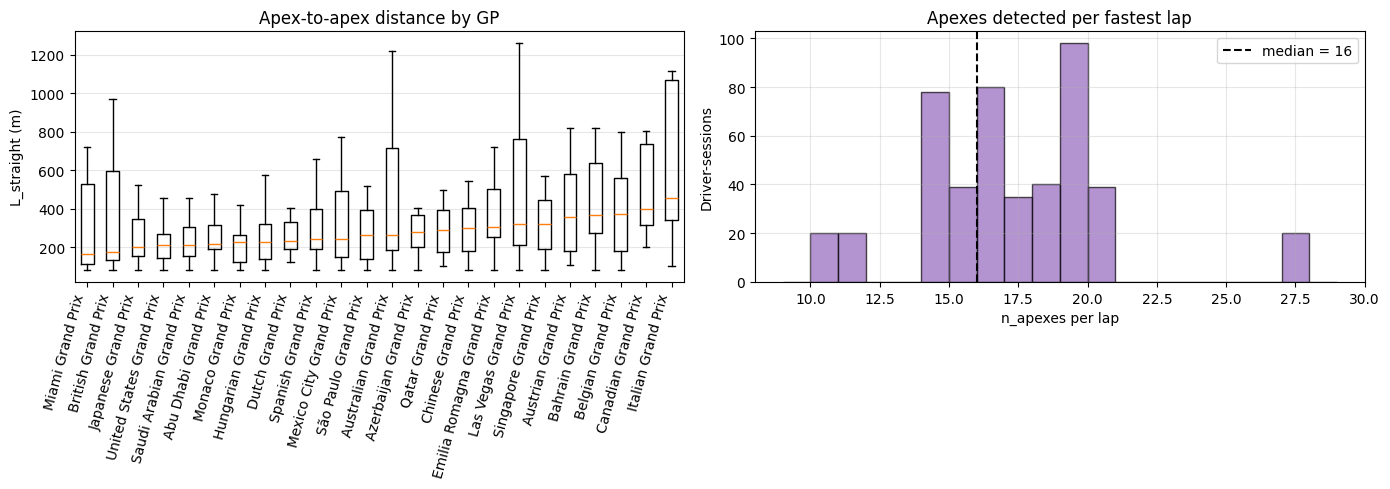

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L_straight per GP
order = df.groupby('gp')['L_straight_m'].median().sort_values().index
gp_data = [df[df['gp'] == gp]['L_straight_m'].values for gp in order]
axes[0].boxplot(gp_data, tick_labels=order, vert=True, showfliers=False)
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order, rotation=75, ha='right')
axes[0].set_ylabel('L_straight (m)')
axes[0].set_title('Apex-to-apex distance by GP')
axes[0].grid(axis='y', alpha=0.3)

# Apex counts per driver-session
apex_counts = df.groupby(['gp', 'driver'])['n_apexes'].first()
axes[1].hist(apex_counts, bins=range(9, 30), color='tab:purple',
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('n_apexes per lap')
axes[1].set_ylabel('Driver-sessions')
axes[1].set_title('Apexes detected per fastest lap')
axes[1].grid(alpha=0.3)
axes[1].axvline(apex_counts.median(), color='black', linestyle='--',
                label=f'median = {int(apex_counts.median())}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'geometric_features.pdf', bbox_inches='tight')
plt.show()

### 4a. High apex counts (>22) — hybrid detector over-counting?

The proposal anticipates that the hybrid fallback may over-count
apexes in chicane complexes when `circuit_info` metadata is missing.
These rows tell us where it fired.

In [8]:
high_apex = df[df['n_apexes'] > 22].groupby(['gp', 'driver']).agg(
    n_apexes=('n_apexes', 'first'),
    detector=('detector', 'first'),
    lap_time_s=('lap_time_s', 'first'),
).reset_index().sort_values('n_apexes', ascending=False)
print(f'Driver-sessions with >22 apexes: {len(high_apex)}')
print(f'  via hybrid:       {(high_apex["detector"] == "hybrid").sum()}')
print(f'  via circuit_info: {(high_apex["detector"] == "circuit_info").sum()}')
print()
high_apex.head(15)

Driver-sessions with >22 apexes: 20
  via hybrid:       0
  via circuit_info: 20



,gp,driver,n_apexes,detector,lap_time_s
0,Saudi Arabian Grand Prix,ALB,27,circuit_info,88.109
1,Saudi Arabian Grand Prix,ALO,27,circuit_info,88.303
2,Saudi Arabian Grand Prix,ANT,27,circuit_info,87.798
3,Saudi Arabian Grand Prix,BEA,27,circuit_info,88.536
4,Saudi Arabian Grand Prix,BOR,27,circuit_info,89.462
5,Saudi Arabian Grand Prix,DOO,27,circuit_info,88.739
6,Saudi Arabian Grand Prix,GAS,27,circuit_info,88.025
7,Saudi Arabian Grand Prix,HAD,27,circuit_info,88.418
8,Saudi Arabian Grand Prix,HAM,27,circuit_info,88.102
9,Saudi Arabian Grand Prix,HUL,27,circuit_info,88.782


## 5. Detector usage breakdown

Which GPs actually used `circuit_info` (FIA metadata) vs falling back
to the hybrid detector? `circuit_info` should dominate for 2024+
seasons. Any GP with significant hybrid usage is worth flagging in
the methods chapter.

In [9]:
detector_counts = (
    df.groupby(['gp', 'detector']).size().unstack(fill_value=0)
)
# Ensure both columns exist even if one detector wasn't used
for col in ('circuit_info', 'hybrid'):
    if col not in detector_counts.columns:
        detector_counts[col] = 0
detector_counts = detector_counts[['circuit_info', 'hybrid']]
detector_counts['hybrid_fraction'] = (
    detector_counts['hybrid'] /
    detector_counts.sum(axis=1).replace(0, np.nan)
)
print(detector_counts.sort_values('hybrid_fraction', ascending=False))

detector                   circuit_info  hybrid  hybrid_fraction
gp                                                              
Abu Dhabi Grand Prix                266       0              0.0
Australian Grand Prix               178       0              0.0
Austrian Grand Prix                 180       0              0.0
Azerbaijan Grand Prix               275       0              0.0
Bahrain Grand Prix                  193       0              0.0
Belgian Grand Prix                  289       0              0.0
British Grand Prix                  288       0              0.0
Canadian Grand Prix                 140       0              0.0
Chinese Grand Prix                  226       0              0.0
Dutch Grand Prix                    228       0              0.0
Emilia Romagna Grand Prix           238       0              0.0
Hungarian Grand Prix                263       0              0.0
Italian Grand Prix                  140       0              0.0
Japanese Grand Prix      

## 6. Phase 2 input space: v_exit vs v_entry_target

The OCP will optimise the transition from v_exit (start of sector,
just leaving an apex) to v_entry_target (end of sector, arriving at
next apex). This plot shows the joint distribution the surrogate
will need to cover.

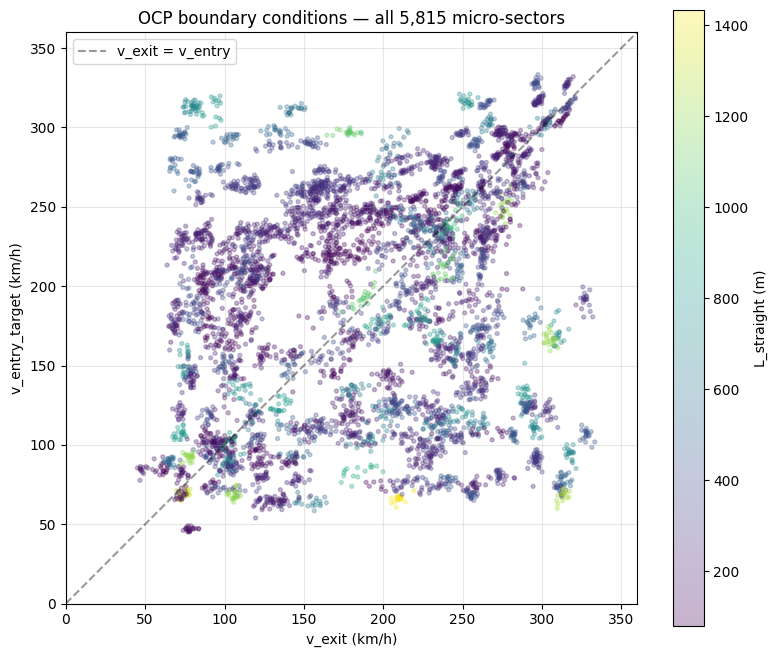

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(df['v_exit_kph'], df['v_entry_target_kph'],
                c=df['L_straight_m'], cmap='viridis',
                alpha=0.3, s=8)
ax.plot([0, 360], [0, 360], 'k--', alpha=0.4, label='v_exit = v_entry')
ax.set_xlabel('v_exit (km/h)')
ax.set_ylabel('v_entry_target (km/h)')
ax.set_title('OCP boundary conditions — all 5,815 micro-sectors')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
ax.set_xlim(0, 360)
ax.set_ylim(0, 360)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('L_straight (m)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ocp_boundary_conditions.pdf', bbox_inches='tight')
plt.show()

## 7. Detector agreement by GP (diagnostics view)

From the diagnostics parquet, showing the per-driver agreement
rates aggregated to per-GP medians — useful for the validation
chapter.

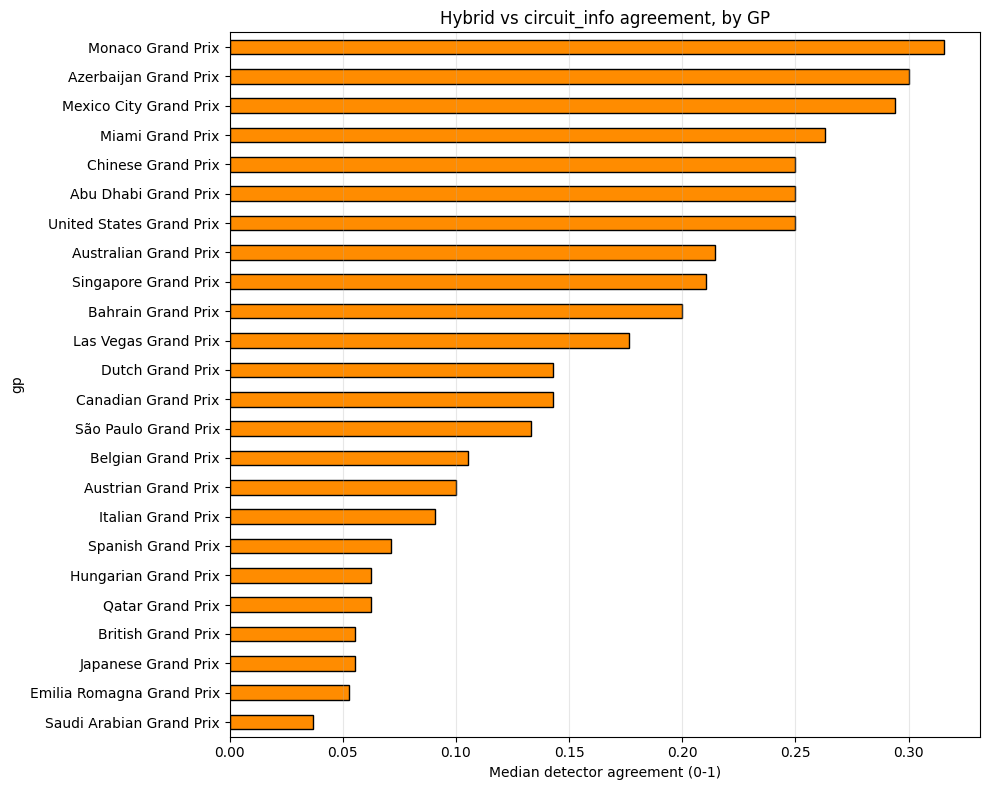

                           n_drivers  median_agreement  median_offset_m
gp                                                                     
Saudi Arabian Grand Prix          20          0.037037              0.0
Emilia Romagna Grand Prix         19          0.052632             14.0
Japanese Grand Prix               20          0.055556              0.0
British Grand Prix                20          0.055556              0.0
Qatar Grand Prix                  20          0.062500              0.0
Hungarian Grand Prix              20          0.062500              0.0
Spanish Grand Prix                20          0.071429             16.0
Italian Grand Prix                20          0.090909              0.0
Austrian Grand Prix               20          0.100000              0.0
Belgian Grand Prix                20          0.105263              0.0
São Paulo Grand Prix              19          0.133333              2.0
Canadian Grand Prix               20          0.142857          

In [11]:
agg_by_gp = diag.groupby('gp').agg(
    n_drivers=('agreement_rate', 'size'),
    median_agreement=('agreement_rate', 'median'),
    median_offset_m=('median_offset_m', 'median'),
).sort_values('median_agreement')

fig, ax = plt.subplots(figsize=(10, 8))
agg_by_gp['median_agreement'].plot(
    kind='barh', ax=ax, color='darkorange', edgecolor='black'
)
ax.set_xlabel('Median detector agreement (0-1)')
ax.set_title('Hybrid vs circuit_info agreement, by GP')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'detector_agreement_per_gp.pdf', bbox_inches='tight')
plt.show()

print(agg_by_gp)

## 8. Elevation channel diagnostic (Z review)

Z (elevation) was excluded from the production feature matrix after the
Monaco run produced physically impossible 280 m sector ranges. This
section pulls Z directly from FastF1 — bypassing the production pipeline
— so the corruption pattern can be visually inspected and the exclusion
decision verified.

Cache is already warm from the season run, so re-loading these sessions
is fast (~1-2 s each). If you've cleared `fastf1_cache/`, expect ~30 s
per session on the first run.

In [12]:
import fastf1
from scipy.signal import medfilt, savgol_filter
from f1_pipeline.telemetry import resample_uniform

# Kernel CWD is the workspace root, so f1_pipeline imports work directly
# and fastf1_cache/ is right here.
fastf1.Cache.enable_cache('fastf1_cache')

# Four representative circuits chosen to span the relevant cases:
#   Monaco       - known tunnel corruption (negative control)
#   Belgian      - genuine ~40 m climb at Eau Rouge (should look clean)
#   British      - nearly flat (positive control)
#   United States - real Turn 1 elevation change (should be clean)
DIAGNOSTIC_GPS = ['Monaco', 'Belgian', 'British', 'United States']

def load_fastest_lap_telemetry(year, gp, session_type='Q'):
    """Pull telemetry for the session's fastest lap (any driver)."""
    ses = fastf1.get_session(year, gp, session_type)
    ses.load(telemetry=True, weather=False, messages=False)
    laps = ses.laps.dropna(subset=['LapTime'])
    fastest = laps.loc[laps['LapTime'].idxmin()]
    tel = fastest.get_telemetry()[['Distance', 'X', 'Y', 'Z']].copy()
    drv_abbr = ses.get_driver(fastest['DriverNumber'])['Abbreviation']
    return tel.reset_index(drop=True), drv_abbr

raw_z = {}
for gp in DIAGNOSTIC_GPS:
    tel, drv = load_fastest_lap_telemetry(2025, gp)
    raw_z[gp] = {'tel': tel, 'driver': drv}
    z = tel['Z'].to_numpy()
    print(f'{gp:14s} ({drv}): n={len(z):4d}, '
          f'Z range = {z.max() - z.min():6.1f} m '
          f'(min={z.min():7.1f}, max={z.max():7.1f})')

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '44', '1', '6', '14', '31', '30', '23', '55', '22', '27', '63', '12', '5', '87', '10', '18', '43']
core           INFO 	Loading data for Belgian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Monaco         (NOR): n= 521, Z range =  419.1 m (min=  475.9, max=  895.0)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '1', '23', '63', '22', '6', '30', '5', '31', '87', '10', '27', '55', '44', '43', '12', '14', '18']
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Belgian        (NOR): n= 758, Z range = 1023.1 m (min= 3654.9, max= 4678.0)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '63', '44', '16', '12', '87', '14', '10', '55', '22', '6', '23', '31', '30', '5', '18', '27', '43']
events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


British        (VER): n= 639, Z range =  113.1 m (min= 1961.9, max= 2075.0)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '16', '63', '44', '81', '12', '87', '55', '14', '27', '30', '22', '10', '43', '5', '31', '18', '23', '6']


United States  (VER): n= 709, Z range =  303.5 m (min= 1265.6, max= 1569.1)


### 8a. Raw Z traces — visual inspection

Plot each circuit's Z(distance) trace. Real elevation profiles should be
smooth-ish (vehicle dynamics limit the rate of altitude change to ~12-15%
gradient). Corrupted Z appears as either sharp spikes or sustained
implausible offsets.

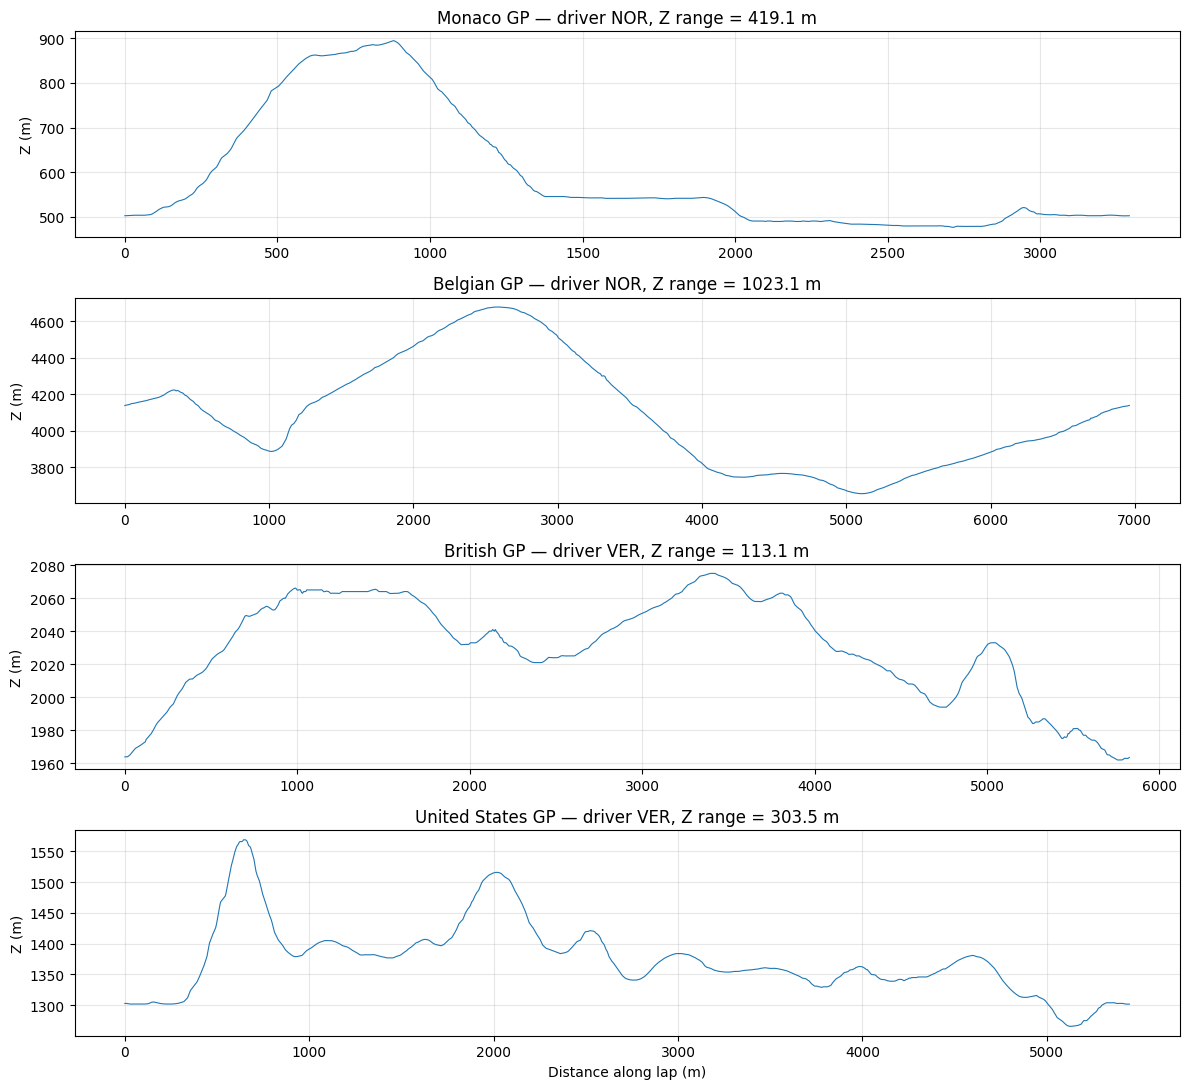

In [13]:
fig, axes = plt.subplots(len(DIAGNOSTIC_GPS), 1, figsize=(12, 11),
                          sharex=False)
for ax, gp in zip(axes, DIAGNOSTIC_GPS):
    tel = raw_z[gp]['tel']
    drv = raw_z[gp]['driver']
    z = tel['Z'].to_numpy()
    ax.plot(tel['Distance'], z, lw=0.8, color='tab:blue')
    ax.set_title(
        f'{gp} GP — driver {drv}, Z range = {z.max() - z.min():.1f} m'
    )
    ax.set_ylabel('Z (m)')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Distance along lap (m)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'z_raw_traces_per_circuit.pdf', bbox_inches='tight')
plt.show()

### 8b. Filter effectiveness on Monaco

Test whether the corruption is recoverable by progressively more
aggressive filtering. If any filter produces a Z range close to Monaco's
real ~32 m differential, that filter is a viable rescue strategy. If
none does, exclusion is the right call.

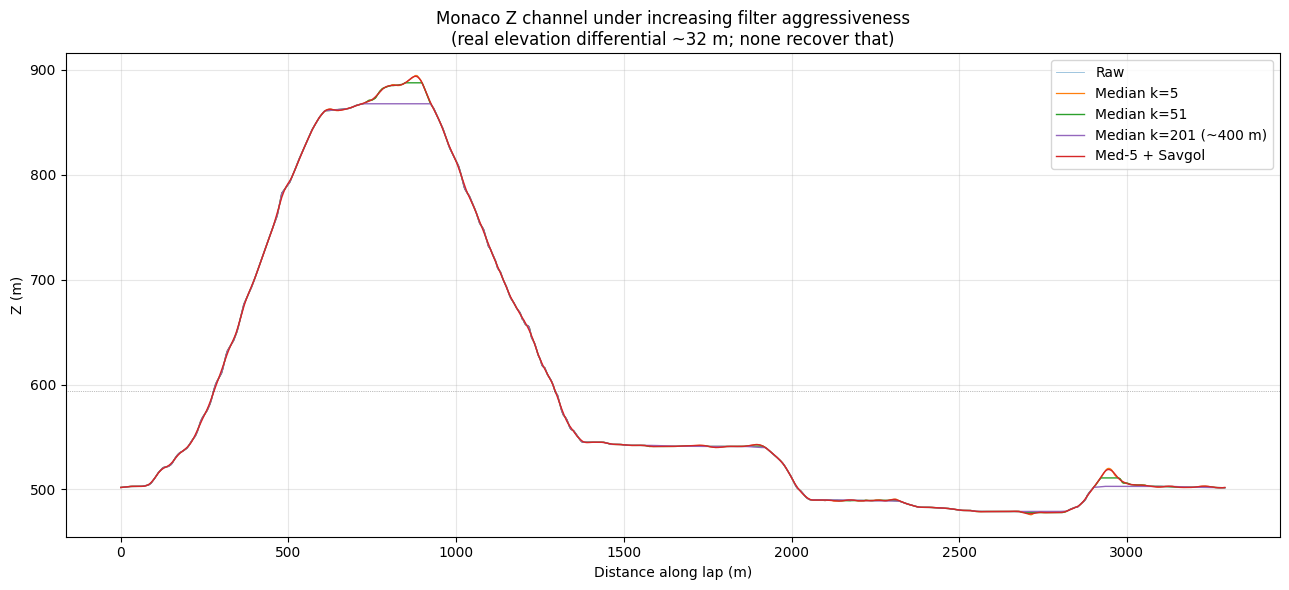


Monaco Z range under each filter (real ~32 m):
  Raw         :   419.0 m
  Median k=5  :   418.5 m
  Median k=51 :   409.6 m
  Median k=201:   388.6 m
  Med-5+Savgol:   417.0 m


In [14]:
tel_monaco_u = resample_uniform(raw_z['Monaco']['tel'], dx=2.0)
z_raw = tel_monaco_u['Z'].to_numpy()

z_med5 = medfilt(z_raw, 5)
z_med51 = medfilt(z_raw, 51)
z_med201 = medfilt(z_raw, 201)
z_med5_savgol = savgol_filter(z_med5, 31, 3)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(tel_monaco_u['Distance'], z_raw,
        lw=0.6, color='tab:blue', alpha=0.5, label='Raw')
ax.plot(tel_monaco_u['Distance'], z_med5,
        lw=0.9, color='tab:orange', label='Median k=5')
ax.plot(tel_monaco_u['Distance'], z_med51,
        lw=1.0, color='tab:green', label='Median k=51')
ax.plot(tel_monaco_u['Distance'], z_med201,
        lw=1.0, color='tab:purple', label='Median k=201 (~400 m)')
ax.plot(tel_monaco_u['Distance'], z_med5_savgol,
        lw=1.0, color='tab:red', label='Med-5 + Savgol')
ax.axhline(z_raw.mean(), color='black', lw=0.5, ls=':', alpha=0.5)
ax.set_xlabel('Distance along lap (m)')
ax.set_ylabel('Z (m)')
ax.set_title(
    'Monaco Z channel under increasing filter aggressiveness\n'
    "(real elevation differential ~32 m; none recover that)"
)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'monaco_z_filter_comparison.pdf', bbox_inches='tight')
plt.show()

print('\nMonaco Z range under each filter (real ~32 m):')
for name, z in [('Raw         ', z_raw),
                 ('Median k=5  ', z_med5),
                 ('Median k=51 ', z_med51),
                 ('Median k=201', z_med201),
                 ('Med-5+Savgol', z_med5_savgol)]:
    print(f'  {name}: {z.max() - z.min():7.1f} m')

### 8c. Is Monaco corruption session-wide or one bad lap?

Pull every driver's fastest Monaco Q lap and check Z range. If every
driver shows similar corruption, it's a session-wide telemetry feed
issue (broadcast-level), not a single-lap GPS glitch.

In [15]:
monaco_ses = fastf1.get_session(2025, 'Monaco', 'Q')
monaco_ses.load(telemetry=True, weather=False, messages=False)

per_driver_z = []
for drv in monaco_ses.drivers:
    try:
        drv_laps = monaco_ses.laps.pick_drivers(drv).dropna(subset=['LapTime'])
        if drv_laps.empty:
            continue
        fastest = drv_laps.loc[drv_laps['LapTime'].idxmin()]
        z = fastest.get_telemetry()['Z'].to_numpy()
        per_driver_z.append({
            'driver': monaco_ses.get_driver(drv)['Abbreviation'],
            'z_range_m': float(z.max() - z.min()),
            'z_min_m': float(z.min()),
            'z_max_m': float(z.max()),
        })
    except Exception:
        continue

monaco_per_driver = (
    pd.DataFrame(per_driver_z)
    .sort_values('z_range_m', ascending=False)
    .reset_index(drop=True)
)
n_corrupt = (monaco_per_driver['z_range_m'] > 100).sum()
print(f'Drivers with implausible (>100 m) Z range: '
      f'{n_corrupt}/{len(monaco_per_driver)}')
print('\nPer-driver Z ranges (Monaco Q 2025 fastest laps):')
print(monaco_per_driver)

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '44', '1', '6', '14', '31', '30', '23', '55', '22', '27', '63', '12', '5', '87', '10', '18', '43']


Drivers with implausible (>100 m) Z range: 20/20

Per-driver Z ranges (Monaco Q 2025 fastest laps):
   driver   z_range_m     z_min_m     z_max_m
0     ANT  420.161518  475.913963  896.075481
1     STR  420.146038  475.857166  896.003204
2     ALB  420.068579  476.000000  896.068579
3     TSU  420.000000  476.000000  896.000000
4     SAI  419.861566  475.925599  895.787165
5     COL  419.445127  475.855775  895.300902
6     BOR  419.443497  475.888671  895.332168
7     PIA  419.362269  476.000000  895.362269
8     RUS  419.343391  475.982978  895.326370
9     LEC  419.328064  475.712864  895.040928
10    VER  419.232115  475.767885  895.000000
11    GAS  419.168157  475.831843  895.000000
12    NOR  419.111507  475.888493  895.000000
13    ALO  419.100876  475.908431  895.009307
14    OCO  419.001797  475.998203  895.000000
15    HAM  419.000000  476.000000  895.000000
16    HAD  419.000000  476.000000  895.000000
17    BEA  418.311789  475.998899  894.310687
18    LAW  418.111797  475

### 8d. Cross-circuit Z reliability summary

Compare each diagnostic circuit's Z range against its known real
elevation differential. This is the table to lift into the methods
chapter to defend the Z exclusion.

In [16]:
# Published real-world elevation differentials (approximate)
REAL_ELEVATION_M = {
    'Monaco':        32,    # Casino Square to harbour
    'Belgian':       102,   # Eau Rouge to Les Combes — largest in F1
    'British':       16,    # gentle undulation, essentially flat
    'United States': 41,    # Turn 1 climb
}

summary_rows = []
for gp in DIAGNOSTIC_GPS:
    z = raw_z[gp]['tel']['Z'].to_numpy()
    observed = float(z.max() - z.min())
    real = REAL_ELEVATION_M[gp]
    summary_rows.append({
        'gp': gp,
        'observed_z_range_m': observed,
        'real_elevation_m':   real,
        'ratio_observed_real': observed / real,
        'plausible': observed < 1.5 * real,
    })

summary = pd.DataFrame(summary_rows)
print('Z channel plausibility check (ratio < 1.5 = plausible):\n')
print(summary.to_string(index=False))
print(
    f'\nConclusion: '
    f'{summary["plausible"].sum()}/{len(summary)} circuits produce '
    'physically plausible Z data. '
    f'\nExclusion of Z from the feature matrix is justified.'
)

Z channel plausibility check (ratio < 1.5 = plausible):

           gp  observed_z_range_m  real_elevation_m  ratio_observed_real  plausible
       Monaco          419.111507                32            13.097235      False
      Belgian         1023.127762               102            10.030664      False
      British          113.073984                16             7.067124      False
United States          303.453116                41             7.401296      False

Conclusion: 0/4 circuits produce physically plausible Z data. 
Exclusion of Z from the feature matrix is justified.


## 9. Summary & next steps

Print a one-paragraph summary of what to clean up next.

In [17]:
n_slow_drivers = len(slow_laps)
n_slow_sectors = df.merge(
    slow_laps[['gp', 'driver']], on=['gp', 'driver']
).shape[0]
n_low_vmin = len(suspicious)
n_high_apex = len(high_apex)

print(f'''
Phase 1 dataset summary
------------------------
Total micro-sectors:       {len(df):,}
GPs covered:               {df["gp"].nunique()}
Unique drivers:            {df["driver"].nunique()}
Median lap time:           {lap_times["lap_time_s"].median():.2f} s

Cleanup targets for the 107% filter
-----------------------------------
Drivers >107% off pace:    {n_slow_drivers}
Sectors from slow laps:    {n_slow_sectors}
Sectors v_min < 40 km/h:   {n_low_vmin}
Sessions w/ >22 apexes:    {n_high_apex}

Estimated dataset after filtering:
    {len(df) - n_slow_sectors:,} sectors
''')


Phase 1 dataset summary
------------------------
Total micro-sectors:       5,748
GPs covered:               24
Unique drivers:            21
Median lap time:           81.06 s

Cleanup targets for the 107% filter
-----------------------------------
Drivers >107% off pace:    0
Sectors from slow laps:    0
Sectors v_min < 40 km/h:   0
Sessions w/ >22 apexes:    20

Estimated dataset after filtering:
    5,748 sectors

